<a href="https://colab.research.google.com/github/floatbeyond/LAVIS/blob/main/img2llm_vqa_ML_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Img2Prompt-VQA

In [1]:
import sys
if 'google.colab' in sys.modules:
    print('Running in Colab.')
    !pip3 install salesforce-lavis

Running in Colab.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 6.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.7 MB/s eta 0:00:00
   

In [2]:
!pip uninstall numpy -y
!pip uninstall opencv-python -y
!pip uninstall opencv-python-headless -y
!pip uninstall transformers -y

!pip install numpy==1.26.0 # Try this version as it's required by tensorflow
!pip install opencv-python>=4.9.0.80
!pip install opencv-python-headless>=4.9.0.80
!pip install transformers>=4.41.0
!pip install diffusers==0.16.0
!pip install huggingface_hub==0.24.6
!pip install spacy==3.6.0
!pip install peft==0.10.0
!pip install moviepy==1.0.3

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: opencv-python 4.11.0.86
Uninstalling opencv-python-4.11.0.86:
  Successfully uninstalled opencv-python-4.11.0.86
Found existing installation: opencv-python-headless 4.5.5.64
Uninstalling opencv-python-headless-4.5.5.64:
  Successfully uninstalled opencv-python-headless-4.5.5.64
Found existing installation: transformers 4.26.1
Uninstalling transformers-4.26.1:
  Successfully uninstalled transformers-4.26.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 98.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
salesforce-lavis 1.0.2 requires opencv-python-headless==4.5.5.64, which is not installed.
salesforce-lavis 1.0.2 requires 

### Restart Session here!!

In [2]:
import torch
import requests
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np

from lavis.common.gradcam import getAttMap
from lavis.models import load_model_and_preprocess

/usr/local/lib/python3.11/dist-packages/fairscale/experimental/nn/offload.py:19: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_fwd(orig_func)  # type: ignore
/usr/local/lib/python3.11/dist-packages/fairscale/experimental/nn/offload.py:30: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_bwd(orig_func)  # type: ignore


### Load LLM to use

In [ ]:
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, AutoModelForSeq2SeqLM

def load_model(model_selection):
    model = AutoModelForCausalLM.from_pretrained(model_selection)
    tokenizer = AutoTokenizer.from_pretrained(model_selection, use_fast=False)
    return model,tokenizer

# Choose LLM to use
# weights for OPT-6.7B/OPT-13B/OPT-30B/OPT-66B will download automatically
print("Loading Large Language Model (LLM)...")
llm_model, tokenizer = load_model('facebook/opt-6.7b')  # ~13G (FP16)
# llm_model, tokenizer = load_model('facebook/opt-13b') # ~26G (FP16)
# llm_model, tokenizer = load_model('facebook/opt-30b') # ~60G (FP16)
# llm_model, tokenizer = load_model('facebook/opt-66b') # ~132G (FP16)

# you need to manually download weights, in order to use OPT-175B
# https://github.com/facebookresearch/metaseq/tree/main/projects/OPT
# llm_model, tokenizer = load_model('facebook/opt-175b')

Loading Large Language Model (LLM)...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/651 [00:00<?, ?B/s]

pytorch_model.bin.index.json:   0%|          | 0.00/41.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

pytorch_model-00002-of-00002.bin:   0%|          | 0.00/3.36G [00:00<?, ?B/s]

pytorch_model-00001-of-00002.bin:   0%|          | 0.00/9.96G [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/44.0k [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

### Load an example image and question

What are the black things in the salad?


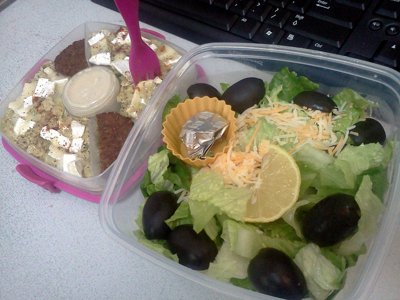

In [3]:
img_url = 'https://storage.googleapis.com/sfr-vision-language-research/LAVIS/projects/pnp-vqa/demo.png'
raw_image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

# raw_image = Image.open("./demo.png").convert("RGB")
question = "What are the black things in the salad?"
print(question)
display(raw_image.resize((400, 300)))

### Load Img2Prompt-VQA model

In [5]:
# setup device to use
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
model, vis_processors, txt_processors = load_model_and_preprocess(name="img2prompt_vqa", model_type="base", is_eval=True, device=device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

  9%|▉         | 319M/3.43G [00:03<01:17, 43.0MB/s]

### Preprocess image and text inputs

In [ ]:
image = vis_processors["eval"](raw_image).unsqueeze(0).to(device)
question = txt_processors["eval"](question)

samples = {"image": image, "text_input": [question]}

Img2Prompt-VQA utilizes 4 submodels to perform VQA:
1. Image-Question Matching
Compute the relevancy score of image patches with respect to the question using GradCAM

In [ ]:
samples = model.forward_itm(samples=samples)

In [ ]:
# Gradcam visualisation
dst_w = 720
w, h = raw_image.size
scaling_factor = dst_w / w

resized_img = raw_image.resize((int(w * scaling_factor), int(h * scaling_factor)))
norm_img = np.float32(resized_img) / 255
gradcam = samples['gradcams'].reshape(24,24).cpu().numpy() # Convert to NumPy
avg_gradcam = getAttMap(norm_img, gradcam, blur=True)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(avg_gradcam)
ax.set_yticks([])
ax.set_xticks([])
print('Question: {}'.format(question))

#### 2. Image Captioning
Generate question-guided captions based on the relevancy score

In [ ]:
samples = model.forward_cap(samples=samples, num_captions=50, num_patches=20)
print('Examples of question-guided captions: ')
samples['captions'][0][:5]

#### 3. Question Generation
Generate synthetic questions using the captions

In [ ]:
samples = model.forward_qa_generation(samples)
print('Sample Question: {} \nSample Answer: {}'.format(samples['questions'][:5], samples['answers'][:5]))

In [ ]:
samples['questions']

#### 4. Prompt Construction
Prepare the prompts for LLM

In [ ]:
Img2Prompt = model.prompts_construction(samples)

#### 5. Load LLM and Predict Answers


In [ ]:
# In this notebook, we only use CPU for LLM inference
# To run inference on GPU, see https://github.com/CR-Gjx/Img2Prompt for reference
device = "cpu"

def postprocess_Answer(text):
    for i, ans in enumerate(text):
        for j, w in enumerate(ans):
            if w == '.' or w == '\n':
                ans = ans[:j].lower()
                break
    return ans

Img2Prompt_input = tokenizer(Img2Prompt, padding='longest', truncation=True, return_tensors="pt").to(device)

assert (len(Img2Prompt_input.input_ids[0])+20) <=2048

outputs_list  = []
outputs = llm_model.generate(input_ids=Img2Prompt_input.input_ids,
                         attention_mask=Img2Prompt_input.attention_mask,
                         max_length=20+len(Img2Prompt_input.input_ids[0]),
                         return_dict_in_generate=True,
                         output_scores=True
                         )
outputs_list.append(outputs)


#### 6. Decoding to answers

In [ ]:
outputs_list

pred_answer = tokenizer.batch_decode(outputs.sequences[:, len(Img2Prompt_input.input_ids[0]):])
pred_answer = postprocess_Answer(pred_answer)

print({"question": question, "answer": pred_answer})